In [12]:
import jax
import jax.numpy as jnp
import optax

# Parameters
N_VECTORS, D_IN, N_OUT = 100, 10, 1_000
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)

# Helper to get off-diagonal dot products
mask = ~jnp.eye(N_VECTORS, dtype=bool)
def get_sims(V):
    return (V @ V.T)[mask]

# Task 0: Sample 100 10D unit vectors
X = jax.random.normal(k1, (N_VECTORS, D_IN))
X = X / jnp.linalg.norm(X, axis=1, keepdims=True)

sims0 = get_sims(X)
print(f"0) Original  - Mean abs dot product: {jnp.mean(jnp.abs(sims0)):.4f}")

# Task 1: Random Linear + ReLU transformation
def transform(W, X):
    H = jax.nn.relu(X @ W)
    return H / (jnp.linalg.norm(H, axis=1, keepdims=True) + 1e-8)

W_rand = jax.random.normal(k2, (D_IN, N_OUT))
H1 = transform(W_rand, X)
sims1 = get_sims(H1)

def print_comparison(name, s_new, s_old):
    mean_val = jnp.mean(jnp.abs(s_new))
    # If absolute dot product decreases, vectors became more orthogonal (distance increased)
    dist_increased = jnp.sum(jnp.abs(s_new) < jnp.abs(s_old)) 
    dist_decreased = jnp.sum(jnp.abs(s_new) > jnp.abs(s_old))
    print(f"{name} - Mean abs dot product: {mean_val:.4f} | Distances increased: {dist_increased} | Distances decreased: {dist_decreased}")

print_comparison("1) Random   ", sims1, sims0)

# Task 2: Optimize W to maximize orthogonality (minimize squared dot products)
@jax.jit
def train_step(W, opt_state, X):
    def loss_fn(W):
        H = transform(W, X)
        return jnp.mean(get_sims(H)**2) 
    
    grads = jax.grad(loss_fn)(W)
    updates, opt_state = optimizer.update(grads, opt_state)
    return optax.apply_updates(W, updates), opt_state

optimizer = optax.adam(0.01)
W_opt = W_rand
opt_state = optimizer.init(W_opt)

# Optimize for 300 steps
for _ in range(13000):
    W_opt, opt_state = train_step(W_opt, opt_state, X)

H2 = transform(W_opt, X)
sims2 = get_sims(H2)

print_comparison("2) Optimized", sims2, sims0)

0) Original  - Mean abs dot product: 0.2577
1) Random    - Mean abs dot product: 0.3330 | Distances increased: 2568 | Distances decreased: 7332
2) Optimized - Mean abs dot product: nan | Distances increased: 0 | Distances decreased: 0


In [50]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

folder = Path(".").resolve() / "runs" / "le_grid_first_20260414_170855"

df = []
for ent in folder.iterdir():

    if not ent.name.endswith(".json"):
        continue

    name, _, budget, _, model, _ = ent.name.split("_")
    budget = int(float(budget))
    model = int(model)
    
    with open(ent, "r") as f:
        metrics = json.load(f)

    metrics = pd.DataFrame(metrics)
    metrics["epoch"] = np.arange(len(metrics))
    metrics["model"] = model
    metrics["budget"] = budget
    df.append(metrics)

df = pd.concat(df, ignore_index=True)
df.shape

(500, 12)

In [16]:
df.sample(3)

,validation_loss,validation_accuracy_metric,validation_ce_loss,validation_load_distribution_loss,validation_specialization_loss,loss,ce_loss,load_distribution_loss,specialization_loss,epoch,model,budget
372,2.844196,0.635547,2.844184,0.000011,3.345398e-08,0.044541,0.044532,0.000009,3.354012e-08,22,15,1000000
487,1.131088,0.623438,1.131086,0.000001,3.406327e-08,0.738068,0.738067,0.000001,3.408341e-08,12,20,100000
305,1.203730,0.653125,1.203724,0.000005,3.339519e-08,0.541938,0.541933,0.000005,3.344253e-08,5,10,1000000


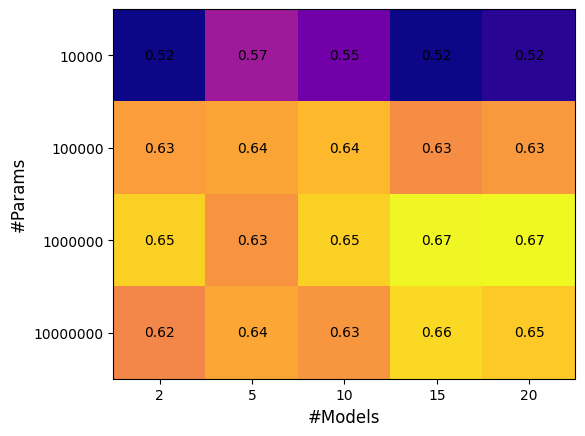

In [52]:

from matplotlib import pyplot as plt


def best_accuracy(g: pd.DataFrame):
    return g["validation_accuracy_metric"].max()


def last_accuracy(g: pd.DataFrame):
    g = g.sort_values("epoch")
    last_tl = g.tail(1)["validation_accuracy_metric"].values[0]
    return last_tl


def last_validation_loss(g: pd.DataFrame):
    g = g.sort_values("epoch")
    last_tl = g.tail(1)["validation_ce_loss"].values[0]
    return last_tl

def last_training_error(g: pd.DataFrame):
    g = g.sort_values("epoch")
    last_tl = g.tail(1)["ce_loss"].values[0]
    return last_tl
    

def plot_square_metrics(agg: pd.DataFrame):

    agg = agg.sort_index(axis=0).sort_index(axis=1)

    # agg = agg.iloc[1:, :]
    
    fig, ax = plt.subplots()
    ax.matshow(agg, cmap="plasma")
    ax.set_xticks(np.arange(len(agg.columns)), agg.columns)
    ax.xaxis.tick_bottom()
    ax.set_xlabel("#Models", fontsize=12)

    ax.set_yticks(np.arange(len(agg.index)), agg.index)
    ax.set_ylabel("#Params", fontsize=12)

    for (i, j), val in np.ndenumerate(agg):
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                color='white' if val < agg.values.max()/2 else 'black')

agg = df.groupby(["budget", "model"]).apply(best_accuracy).unstack()
plot_square_metrics(agg)

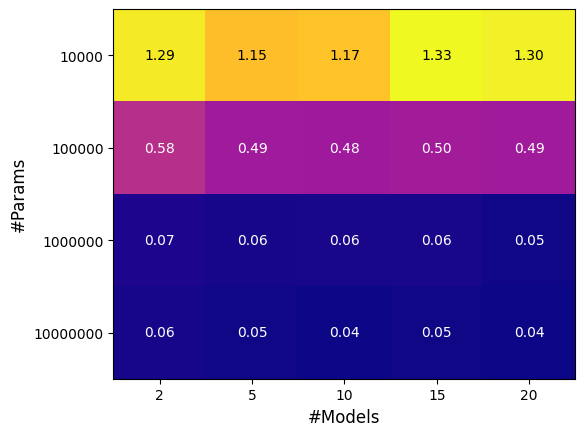

In [37]:
agg = df.groupby(["budget", "model"]).apply(last_training_error).unstack()
plot_square_metrics(agg)

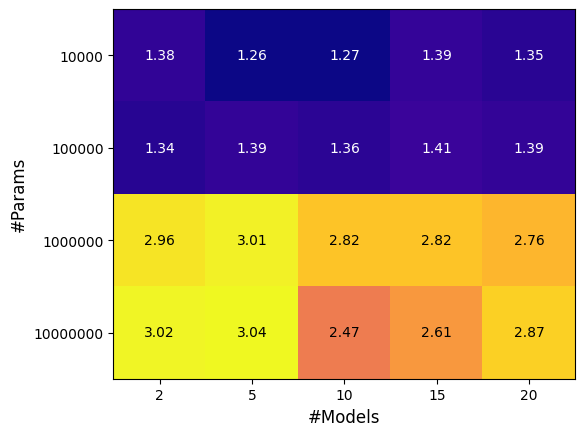

In [39]:
agg = df.groupby(["budget", "model"]).apply(last_validation_loss).unstack()
plot_square_metrics(agg)

In [2]:
import optuna
import pandas as pd
from pathlib import Path

def extract_results(folder: Path, method: str) -> pd.DataFrame:
    storage_path: str = f"sqlite:///{folder / f'study_{method}.db'}"
    
    study: optuna.Study = optuna.load_study(
        study_name=method,
        storage=storage_path
    )
    
    return study.trials_dataframe(), study

hyper, study = extract_results(Path(".").resolve() / "runs" / "hyper_le_20260414_102214", "le")

In [3]:
from optuna.importance import FanovaImportanceEvaluator
from optuna.visualization import plot_param_importances

# 1. Calculate numerical importance
importance = optuna.importance.get_param_importances(
    study, 
    evaluator=FanovaImportanceEvaluator()
)

# 2. Visualize the results
plot_param_importances(study, evaluator=FanovaImportanceEvaluator())

In [5]:
study.best_params

{'n_models': 48,
 'body_layer_0': 35,
 'body_layer_1': 18,
 'body_layer_2': 12,
 'out_layer_0': 33,
 'out_layer_1': 35,
 'delegation_layer_0': 1,
 'delegation_layer_1': 1,
 'load_distribution_lambda': 3.79037090323339e-05,
 'load_distribution_temperature': 0.30850494736052386,
 'specialization_lambda': 4.312424879256117e-06,
 'long_delegations_penalty': 0.3078043150301015,
 'solver': 'sink_one'}

In [4]:
optuna.visualization.plot_slice(study, params=list(study.best_params.keys()))

In [5]:
optuna.visualization.plot_parallel_coordinate(study)

In [10]:
fig = optuna.visualization.plot_contour(
    study, 
    params=["load_distribution_lambda", "specialization_lambda"]
)

# Set width and height to the same value for a square ratio
fig.update_layout(
    width=800, 
    height=800,
    autosize=False
)

fig.show()

In [11]:
fig = optuna.visualization.plot_contour(
    study, 
    params=["load_distribution_lambda", "load_distribution_temperature"]
)

# Set width and height to the same value for a square ratio
fig.update_layout(
    width=800, 
    height=800,
    autosize=False
)

fig.show()

In [ ]:
hyper.groupby("params_solver")["value"].describe()

,count,mean,std,min,25%,50%,75%,max
params_solver,,,,,,,,
sink_many,105.0,-0.608637,0.057666,-0.645182,-0.629557,-0.619792,-0.608724,-0.108724
sink_one,205.0,-0.640433,0.022136,-0.665234,-0.651563,-0.646875,-0.638281,-0.498698


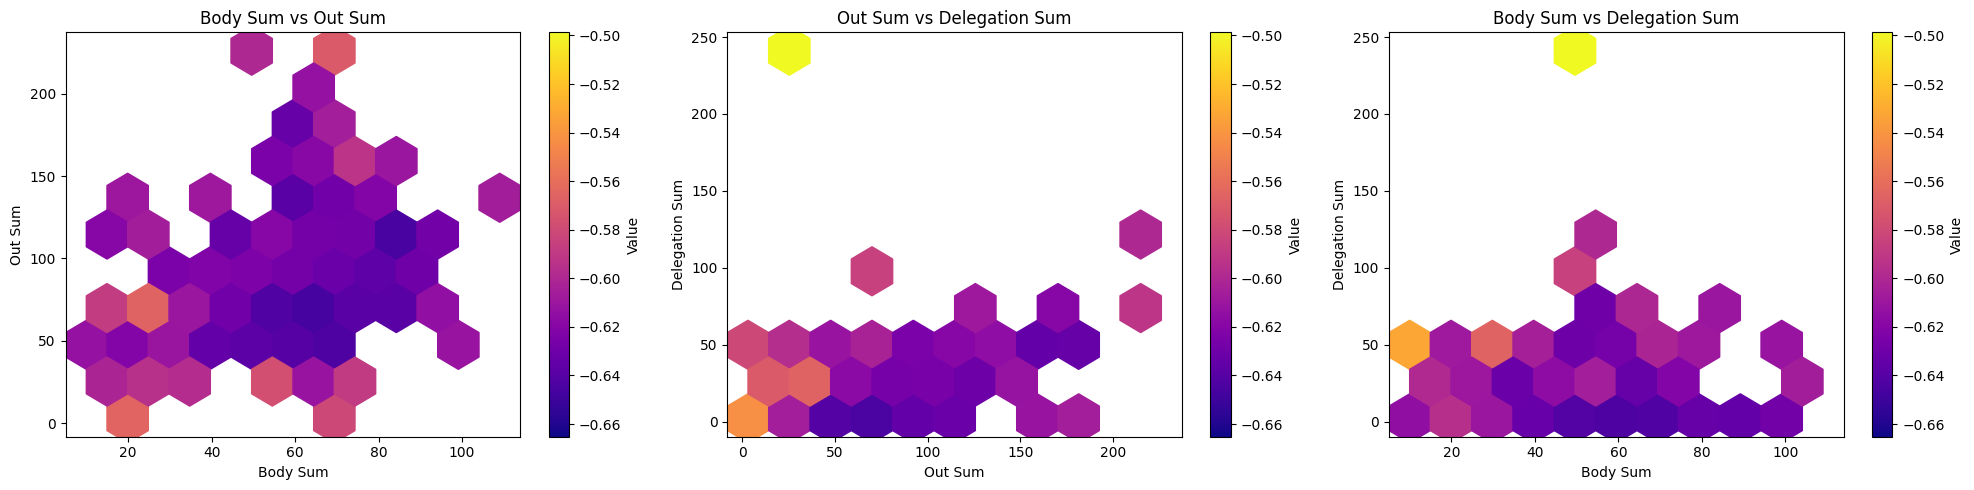

In [38]:
import matplotlib.pyplot as plt

def plot_what_i_want(hyper: pd.DataFrame):
    hyper = hyper[hyper["value"].notnull() & (hyper["value"] < -0.4)].copy()

    body_sum = hyper[hyper.columns[hyper.columns.str.contains("body")]].sum(axis=1)
    out_sum = hyper[hyper.columns[hyper.columns.str.contains("out")]].sum(axis=1)
    delegation_sum = hyper[hyper.columns[hyper.columns.str.contains("delegation")]].sum(axis=1)
    value = hyper["value"]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plots = [
        (body_sum, out_sum, "Body Sum", "Out Sum"),
        (out_sum, delegation_sum, "Out Sum", "Delegation Sum"),
        (body_sum, delegation_sum, "Body Sum", "Delegation Sum")
    ]

    vmin, vmax = value.min(), value.max()

    for ax, (x, y, xl, yl) in zip(axes, plots):
        hb = ax.hexbin(x, y, C=value, gridsize=10, cmap='plasma', mincnt=1, vmin=vmin, vmax=vmax)
        fig.colorbar(hb, ax=ax, label='Value')
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_title(f"{xl} vs {yl}")

    plt.tight_layout()
    plt.show()

plot_what_i_want(hyper)

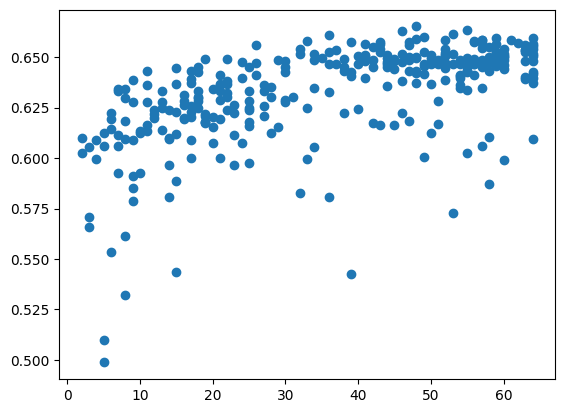

In [41]:
cleaned = hyper[hyper["value"].notnull() & (hyper["value"] < -0.4)].copy()
plt.scatter(cleaned["params_n_models"], -cleaned["value"])

Text(0, 0.5, '#Accuracy')

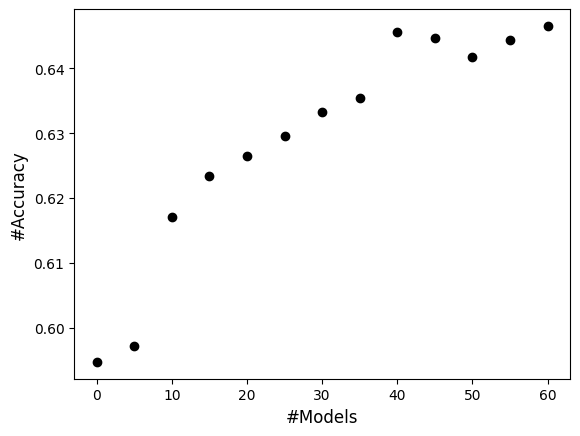

In [55]:
# Bin by 5s, take the mean, and plot
binned = cleaned.groupby(cleaned["params_n_models"] // 5 * 5)["value"].mean()

plt.scatter(binned.index, -binned.values, color='black')
plt.xlabel("#Models", fontsize=12)
plt.ylabel("#Accuracy", fontsize=12)

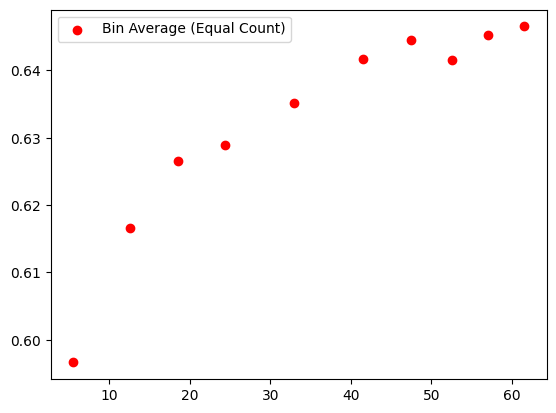

In [45]:
# Create 10 bins with an equal number of data points
cleaned['bins'] = pd.qcut(cleaned['params_n_models'], q=10, duplicates='drop')

# Group by the bins and calculate the mean for each
binned = cleaned.groupby('bins', observed=True)['value'].mean()

# For the x-axis, use the midpoint or the label of the bin
bin_centers = [b.mid for b in binned.index]

plt.scatter(bin_centers, -binned.values, color='red', label='Bin Average (Equal Count)')
plt.legend()

(array([ 83., 106.,  59.,  37.,  10.,   6.,   2.,   2.,   1.,   2.]),
 array([-0.66523439, -0.64858074, -0.6319271 , -0.61527345, -0.59861981,
        -0.58196616, -0.56531252, -0.54865887, -0.53200523, -0.51535158,
        -0.49869794]),
 <BarContainer object of 10 artists>)

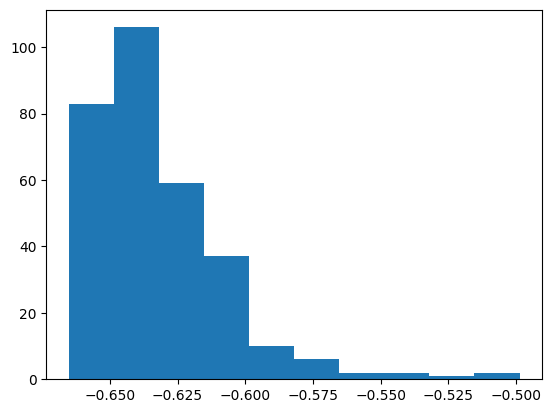

In [48]:
plt.hist(cleaned["value"])

/home/viktor/Documents/liquid/.venv/lib/python3.12/site-packages/pandas/core/series.py:899: RuntimeWarning: invalid value encountered in cast
  arr = np.asarray(values, dtype=dtype)


ValueError: z array must not contain non-finite values within the triangulation

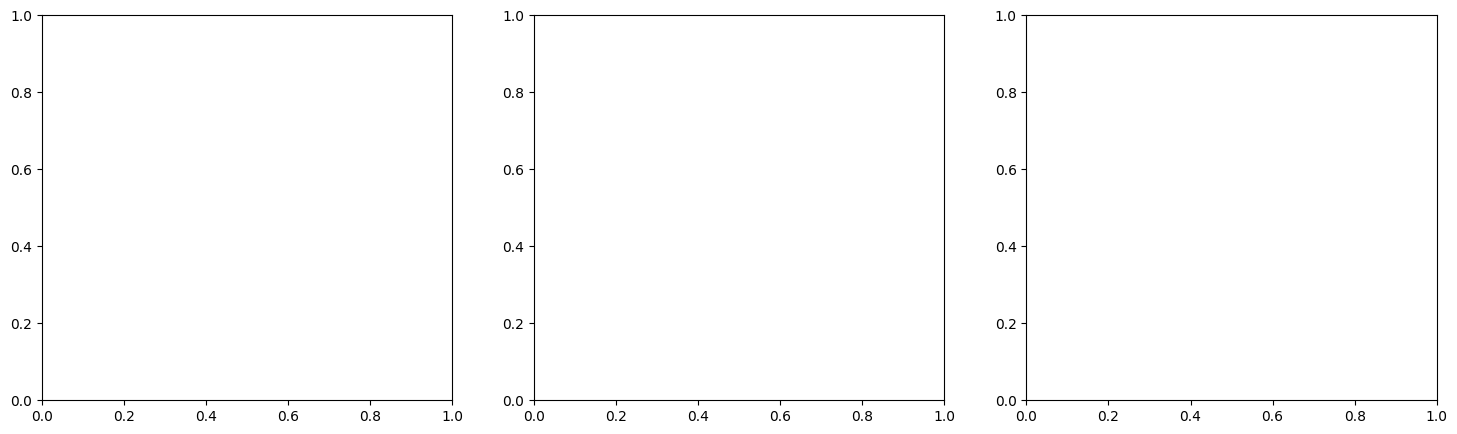

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plots = [
    (body_sum, out_sum, "Body Sum", "Out Sum"),
    (out_sum, delegation_sum, "Out Sum", "Delegation Sum"),
    (body_sum, delegation_sum, "Body Sum", "Delegation Sum")
]

for ax, (x, y, xl, yl) in zip(axes, plots):
    cp = ax.tricontourf(x, y, value, levels=20, cmap='viridis')
    fig.colorbar(cp, ax=ax)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"{xl} vs {yl}")

plt.tight_layout()
plt.show()